In [1]:
import numpy as np
import torch.nn.functional as F
from matplotlib import pyplot as plt
import torch

import sys
import os
from scipy.stats import poisson

sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))

$z \sim P(\lambda)$

$p(z = k) = \frac{\lambda^k e^{-\lambda}}{k!}$

In [ ]:
def log_poisson_rate(lam, unpperbound: int = 8):
    k = torch.arange(unpperbound, device=lam.device).float()
    return k * lam.log().unsqueeze(-1) - lam - torch.lgamma(k + 1)


def aggregate_samples(gumbel_samples: torch.Tensor, upperbound: int = 8):
    k = torch.arange(upperbound, device=gumbel_samples.device).float()
    return gumbel_samples @ k

In [18]:
log_poisson_rate(lam).exp()

tensor([0.1353, 0.2707, 0.2707, 0.1804, 0.0902, 0.0361, 0.0120, 0.0034])

3 = [0, 0, 0, 1, 0, 0, 0, 0]
5 = [0, 0, 0, 0, 0, 1, 0, 0]

one-hot 样本

0 * 0 + 0 * 1 + 0 * 2 + 1 * 3

$z \sim P(\lambda),\ \lambda = encoder(x)$

$z \sim N(\mu, \sigma),\ \mu,\sigma = encoder(x)$

$\frac{\partial z}{\partial \mu}$ 能求，$\frac{\partial z}{\partial \sigma}$ 能求

$\frac{\partial z}{\partial \lambda}$ 不能求

reparameterization trick (重参数化技巧)

$\epsilon \sim N(0, 1) \to z = \epsilon * \sigma + \mu$

$\pi = [\pi_0, \pi_1, \dots, \pi_{M-1}] = pp(\lambda)$

$\tilde{z} = [z_0, z_1, \dots, z_{M-1}] \sim Categorical(\pi)$ one-hot 样本

$z = \sum_{m=0}^{M-1} m * z_m$ 把 one-hot 样本变回整数样本

先采样 $M$ 个 $\epsilon = [\epsilon_0, \epsilon_1, \dots, \epsilon_{M-1}] \sim Gumbel(0, 1)$ 的样本

$y = \ln \pi + \epsilon$

$\tilde{z} = Softmax(y / \tau)$

In [2]:
lam = torch.tensor(2.0)

In [34]:
F.gumbel_softmax(torch.tensor([0.2, 0.3, 0.5]).log(), tau=0.1)

tensor([6.6215e-13, 9.9984e-01, 1.6145e-04])

(array([1.47798742, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        2.96645702, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        2.75681342, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        1.85534591, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.94339623, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([-0.05,  0.05,  0.15,  0.25,  0.35,  0.45,  0.55,  0.65,  0.75,
         0.85,  0.95,  1.05,  1.15,  1.25,  1.35,  1.45,  1.55,  1.65,
         1.75,  1.85,  1.95,  2.05,  2.15,  2.25,  2.35,  2.45,  2.55,
         2.65,  2.75,  2.85,  2.95,  3.05,  3.15,  3.25,  3.35,  3.45,
         3.55,  3.65,  3.75,  3.85

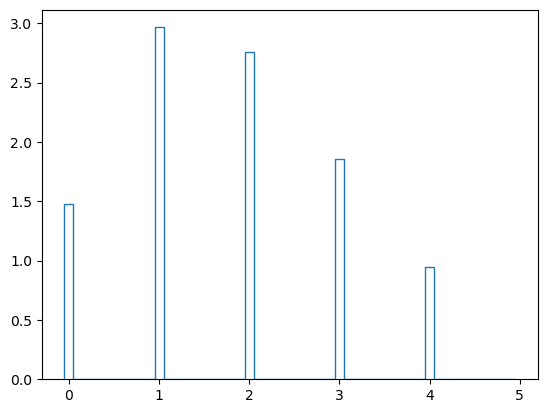

In [12]:
z = torch.poisson(lam.unsqueeze(0).repeat(1000))
plt.hist(
    z.numpy(),
    density=True,
    bins=np.arange(-0.05, 5, 0.1),
    color="C0",
    # label=temp,
    fill=False,
    histtype="step",
)